# INTRODUCTION
This module focuses on four things:
1. Encoding- In module 1, we had scaled volume and weight into values between 1 and 0. When working with information, you may want to instead use the technique of encoding data.
2. Single layer and multilayer Neural Networks - We introduced a very simple 2-input perceptron.  In this module, we introduce single layer and multilayer Neural Networks to build a trained model. For the single layer network, we will show the matrix level calculations.
3. AI Frameworks -  As we go to multilayer, we will introduce Tensorflow and the concept of using AI frameworks.
4. Inferences - This is typically seen as using a trained model to make predictions on new data. To demonstrate inference, we are going to do use an example of the Exclusive OR (XOR). That we only want to indicate a TRUE when only 1 of the inputs is a 1.  We will train a model on purposely imperfect data. Then we will run that model to see how well it performs in picking out and performing like a true XOR.
5. Reinforcement Learning - This is the practice of updating the learning.  Taking a model and doing further modifications to intake new data and new states. The combination of Inference and Reinforcemnt learning is an important steps towards 

Installing all the libraries

In [1]:
!pip install pandas numpy matplotlib datasets

# 1 PAIRWISE LINEAR ENCODER - with Fish
Let us take the case of fish from Module 1. We could create more classifiers from the original dataset. As per the Scatter Plot below, PIKES are an even bigger fish and live on a different Weight / Volume line. 

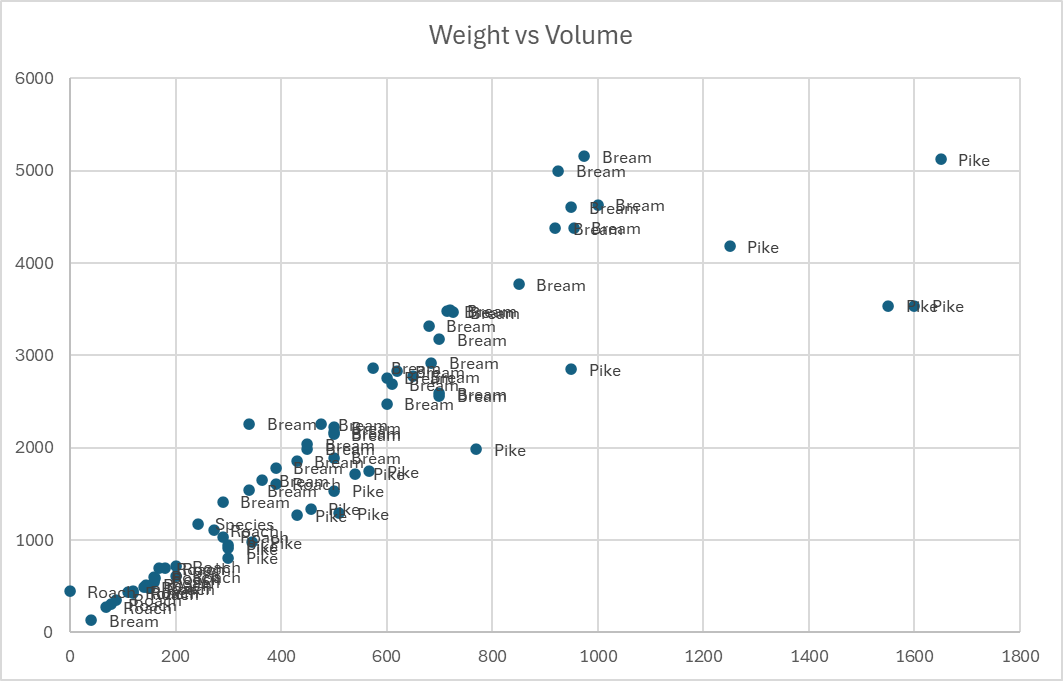

We could create a Linear Classifier that determines if, as our marine biologist collect fish, weigh them and measure them, determine if a fish is a ROACH, a BREAM, or a PIKE. The example below shows a flow diagram -- that for each sample of fish measured, we start to store the results of the three comparison Linear Classifiers.  That we do the determination based on BREAM vs ROACH; BREAM vs PIKE; and ROACH vs PIKE.  

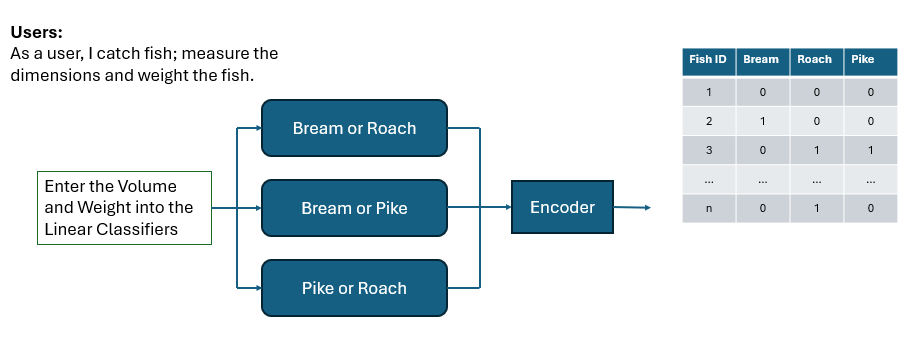

Two things could happen. First, the equations for the linear classifiers are generically now:
* w00*x + w10*y + b0 = prediction(BREAM vs ROACH)
* w01*x + w11*y + b1 = prediction(BREAM vs PIKE)
* w02*x + w12*y + b2 = prediction(ROACH vs PIKE)

If we think of this as matrix math -- those could be combined into:  

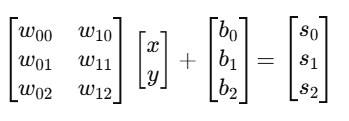

Which, if we start to draw this with the classic Neural Network diagram of:  

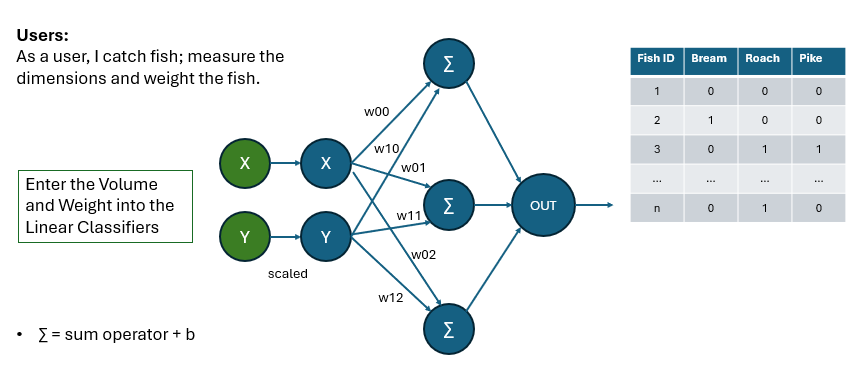


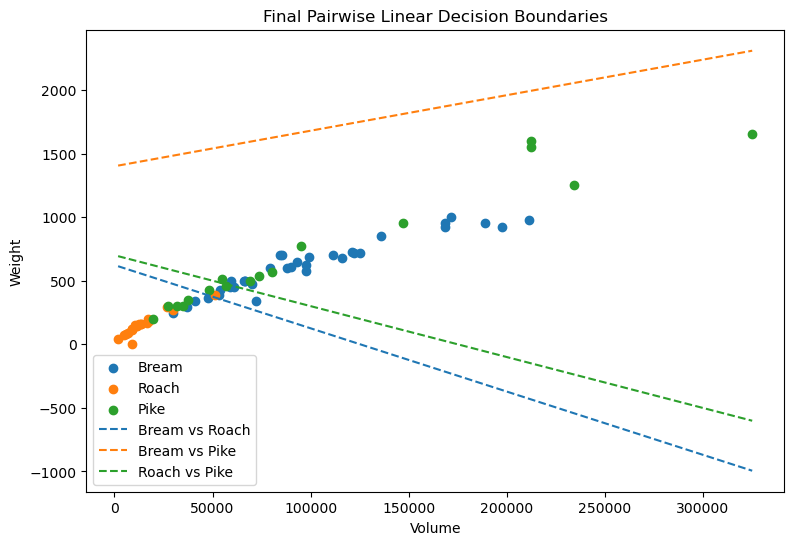

In [2]:
# ============================================================
# Part 1. Training a Pairwise Network
# ============================================================
"""
Trains 3 linear classifiers simultaneously:
  Bream vs Roach
  Bream vs Pike
  Roach vs Pike
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# ============================================================
# Step 0. Load data
# ============================================================

df_load = load_dataset("scikit-learn/Fish")
df = df_load["train"].to_pandas()

df["Volume"] = df["Height"] * (df["Length2"] ** 2) * df["Width"]

# Keep only 3 species
df3 = df[df["Species"].isin(["Bream", "Roach", "Pike"])].copy()

X = df3[["Volume", "Weight"]].values

# Species → class index
species_map = {"Bream": 0, "Roach": 1, "Pike": 2}
y_class = df3["Species"].map(species_map).values

# ============================================================
# Step 1. Build pairwise labels
# ============================================================

# y[:,0] = Bream vs Roach
# y[:,1] = Bream vs Pike
# y[:,2] = Roach vs Pike

y = np.zeros((len(y_class), 3))

# Bream vs Roach
mask = np.isin(y_class, [0, 1])
y[mask, 0] = np.where(y_class[mask] == 0, +1, -1)

# Bream vs Pike
mask = np.isin(y_class, [0, 2])
y[mask, 1] = np.where(y_class[mask] == 0, +1, -1)

# Roach vs Pike
mask = np.isin(y_class, [1, 2])
y[mask, 2] = np.where(y_class[mask] == 1, +1, -1)

# ============================================================
# Step 2. Standardize features
# ============================================================

mu = X.mean(axis=0)
sigma = X.std(axis=0)
Xs = (X - mu) / sigma

# ============================================================
# Step 3. Train linear network (2 → 3)
# ============================================================

def sigmoid(z):
    z = np.clip(z, -60, 60)
    return 1.0 / (1.0 + np.exp(-z))

W = np.random.randn(2, 3) * 0.01
b = np.zeros(3)

lr = 0.15
epochs = 50

for _ in range(epochs):
    scores = Xs @ W + b          # (N,3)
    margins = y * scores
    mask = (y != 0)

    p = sigmoid(-margins)

    grad_W = np.zeros_like(W)
    grad_b = np.zeros_like(b)

    for k in range(3):
        mk = mask[:, k]
        grad_W[:, k] = np.mean(
            (-y[mk, k][:, None] * Xs[mk]) * p[mk, k][:, None],
            axis=0
        )
        grad_b[k] = np.mean(-y[mk, k] * p[mk, k])

    W -= lr * grad_W
    b -= lr * grad_b

# ============================================================
# Step 4. Convert boundaries back to original scale
# ============================================================

W_orig = W / sigma[:, None]
b_orig = b - (mu @ W_orig)

# ============================================================
# Step 5. Final plot (ONLY final result)
# ============================================================

plt.figure(figsize=(9, 6))

for species, idx in species_map.items():
    pts = df3[y_class == idx]
    plt.scatter(
        pts["Volume"],
        pts["Weight"],
        label=species
    )

x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
xx = np.linspace(x_min, x_max, 300)

labels = [
    "Bream vs Roach",
    "Bream vs Pike",
    "Roach vs Pike"
]

for k in range(3):
    w1, w2 = W_orig[:, k]
    bb = b_orig[k]

    if abs(w2) > 1e-8:
        yy = -(w1 * xx + bb) / w2
        plt.plot(xx, yy, linestyle="--", label=labels[k])

plt.xlabel("Volume")
plt.ylabel("Weight")
plt.title("Final Pairwise Linear Decision Boundaries")
plt.legend()
plt.show()

W_final = W.copy()    # shape (2,3)
b_final = b.copy()    # shape (3,)

# 2 MAKING A PREDICTION
When you look at the resulting prediction network, Bream vs Roach and Roach vs Pike are clearer divides in the data.  But notice -- Bream vs Pike's line isn't as clear.  That is because Pike is made of sparse, mostly large volume and higher weight. Pike overlaps Bream along a slanted direction.

Below is the User Input Prediction model.  And as you will see, it is possible for an entry to end up predicting that a fish is all three -- a BREAM, a ROACH and a PIKE.

In [4]:
# ============================================================
# Part 2. User Input → Prediction (Pairwise Network)
# ============================================================

# ------------------------------------------------------------
# STEP 1: Valid input ranges (from training data)
# ------------------------------------------------------------
length_min, length_max = df3['Length2'].min(), df3['Length2'].max()
width_min,  width_max  = df3['Width'].min(),  df3['Width'].max()
height_min, height_max = df3['Height'].min(), df3['Height'].max()
weight_min, weight_max = df3['Weight'].min(), df3['Weight'].max()

print("Enter values within these ranges:")
print(f"  Length : [{length_min:.1f}, {length_max:.1f}]")
print(f"  Width  : [{width_min:.1f},  {width_max:.1f}]")
print(f"  Height : [{height_min:.1f}, {height_max:.1f}]")
print(f"  Weight : [{weight_min:.1f}, {weight_max:.1f}]")

# ------------------------------------------------------------
# STEP 2: User input
# ------------------------------------------------------------

length = float(input("Length: "))
width  = float(input("Width : "))
height = float(input("Height: "))
weight = float(input("Weight: "))

assert length_min <= length <= length_max
assert width_min  <= width  <= width_max
assert height_min <= height <= height_max
assert weight_min <= weight <= weight_max

# ------------------------------------------------------------
# STEP 3: Feature construction
# ------------------------------------------------------------
volume = height * (length ** 2) * width
x_user = np.array([volume, weight])

x_user_std = (x_user - mu) / sigma

# ------------------------------------------------------------
# STEP 4: Pairwise scores
# ------------------------------------------------------------
scores = x_user_std @ W_final + b_final
# scores[0] → Bream vs Roach
# scores[1] → Bream vs Pike
# scores[2] → Roach vs Pike

# ------------------------------------------------------------
# STEP 5: Majority vote
# ------------------------------------------------------------
votes = {"Bream": 0, "Roach": 0, "Pike": 0}

# Bream vs Roach
if scores[0] >= 0:
    votes["Bream"] += 1
else:
    votes["Roach"] += 1

# Bream vs Pike
if scores[1] >= 0:
    votes["Bream"] += 1
else:
    votes["Pike"] += 1

# Roach vs Pike
if scores[2] >= 0:
    votes["Roach"] += 1
else:
    votes["Pike"] += 1

prediction = max(votes, key=votes.get)

# Optional confidence proxy
confidence = votes[prediction] / 2.0   # max = 1.0 (wins both pairwise tests)

# ------------------------------------------------------------
# STEP 6: Output
# ------------------------------------------------------------
print("\n--- Multiclass Prediction (Pairwise Network) ---")
print(f"Volume computed : {volume:.2f}")
print(f"Pairwise scores :")
print(f"  Bream vs Roach : {scores[0]:.3f}")
print(f"  Bream vs Pike  : {scores[1]:.3f}")
print(f"  Roach vs Pike  : {scores[2]:.3f}")

print("\nVotes:", votes)
print(f"Prediction : {prediction}")
print(f"Confidence : {confidence:.2f}")

Enter values within these ranges:
  Length : [14.1, 63.4]
  Width  : [2.3,  7.5]
  Height : [4.1, 19.0]
  Weight : [0.0, 1650.0]


Length:  30
Width :  5
Height:  10
Weight:  850



--- Multiclass Prediction (Pairwise Network) ---
Volume computed : 45000.00
Pairwise scores :
  Bream vs Roach : 1.268
  Bream vs Pike  : 0.375
  Roach vs Pike  : -0.880

Votes: {'Bream': 2, 'Roach': 0, 'Pike': 1}
Prediction : Bream
Confidence : 1.00
